# Unit 3 - A Data Science campaign with pandas and PCA
This unit covers:
* Essential data wrangling with `pandas`;
* Working with different data types;
* Discerning categorical from numerical features;
* Spotting and interpreting the PCA 'variance bug';
* Working with a public data set.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Essential Python tools and concepts – `pandas`

In this practical we will predominantly be working with the `pandas` library. 


In [2]:
import numpy as np
import pandas as pd

### Pandas Series

A Series is a one-dimensional list of values. 

Note the `NaN` value - it means "Not a Number". Originally this represents an undefined numerical, like the result of a division by zero. It is often used to denote missing values. 

In [3]:
values =[1, 3, 5, np.nan, 6, 8] # a list of values
pd.Series(values)

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

It can have an index associated with each value. 

In [4]:
s = pd.Series(values, index=['a', 'b', 'c', 'd', 'e', 'f'])
s

a    1.0
b    3.0
c    5.0
d    NaN
e    6.0
f    8.0
dtype: float64

####  Task 1
Add a letter to the index. What happens? How do you need to change the values list to fix the error?

**error: Length of values (6) does not match length of index (7)**

**To fix error, we need to add one more elements in the values. So the length of the values will match the length of index**

In [38]:
s = pd.Series(values, index=['a', 'b', 'c', 'd', 'e', 'f','g'])
s

ValueError: Length of values (6) does not match length of index (7)

### Pandas Data Frames
A **data frame** is like a two-dimensional series.

In [5]:
df = pd.DataFrame(np.random.randn(6,4)) # note the size: 6 rows, 4 columns
df

,0,1,2,3
0,0.700924,0.012057,-0.166405,-1.083613
1,-1.100703,-1.826274,-0.415647,0.667514
2,-1.947650,-0.856544,0.850007,-0.703059
3,0.656567,0.513005,2.262193,-1.887386
4,-0.150201,0.693046,-0.506457,0.677511
5,0.780020,2.721925,-0.744913,0.575244


You can pass it an index during construction:

In [6]:
df = pd.DataFrame(np.random.randn(6,4), 
                  index=["row {}".format(i) for i in range(6)]) # note the size: 6 rows, 4 columns
df

,0,1,2,3
row 0,-0.744803,0.507168,-0.983436,0.498503
row 1,-0.666002,-0.161387,0.299596,0.693590
row 2,-1.781086,0.592618,-0.350049,-0.454922
row 3,-0.722426,0.863991,-0.704407,0.210513
row 4,0.112424,-1.580096,1.415522,-0.186023
row 5,0.386557,-1.343416,0.721242,0.357873


Likewise, you can pass column names:

In [7]:
df = pd.DataFrame(np.random.randn(6,4), 
                  index=["row {}".format(i) for i in range(6)],
                  columns=['col {}'.format(i) for i in range(4)]) 
df

,col 0,col 1,col 2,col 3
row 0,0.776547,-0.766057,-0.466205,0.580648
row 1,0.767657,-1.424071,0.440894,-1.464308
row 2,0.452305,1.065774,-0.262844,0.136500
row 3,0.625327,-1.530253,-0.008369,0.716864
row 4,1.264287,0.730756,-1.522679,-0.044044
row 5,-0.070135,-1.070714,-1.332004,-0.225532


You can also construct it from a dictionary:

In [8]:
columns = {'beep': np.random.randn(6),
           'bop': np.random.randn(6),
           'bup': np.random.randn(6),
           'bap': np.random.randn(6)}
df = pd.DataFrame(columns, index=["row {}".format(i) for i in range(6)])
df

,beep,bop,bup,bap
row 0,0.954798,1.017040,0.466200,-0.853548
row 1,0.376799,-0.182942,0.465837,0.239922
row 2,-1.996160,0.681055,-1.182007,0.819201
row 3,-0.030893,-1.079032,-0.922977,0.873766
row 4,0.926192,1.422399,0.971510,-0.761581
row 5,-0.397820,-0.093709,-1.530617,-0.729307


### Data frame addressing
We can now address parts of the data by their row and column names. Columns are addressed like this:

In [9]:
df['bop']

row 0    1.017040
row 1   -0.182942
row 2    0.681055
row 3   -1.079032
row 4    1.422399
row 5   -0.093709
Name: bop, dtype: float64

Note that the return value type is a Series, not like a Data Frame! This is because it's one-dimensional.

Extract multiple columns at once by passing a list of column names. Does not need to be unique!

In [10]:
df[['bop', 'bap', 'bap']]

,bop,bap,bap
row 0,1.017040,-0.853548,-0.853548
row 1,-0.182942,0.239922,0.239922
row 2,0.681055,0.819201,0.819201
row 3,-1.079032,0.873766,0.873766
row 4,1.422399,-0.761581,-0.761581
row 5,-0.093709,-0.729307,-0.729307


Here, the return value is a DataFrame because it's two-dimensional.

Rows use the `.loc` attribute:

In [11]:
df.loc[['row 0', 'row 2']]

,beep,bop,bup,bap
row 0,0.954798,1.017040,0.466200,-0.853548
row 2,-1.996160,0.681055,-1.182007,0.819201


The `.iloc` attribute will allow you to specify the number of the row, instead of its label:

In [12]:
df.iloc[0]

beep    0.954798
bop     1.017040
bup     0.466200
bap    -0.853548
Name: row 0, dtype: float64

It can also use numpy-style addressing for the value matrix:

In [13]:
df.iloc[2,1:4]

bop    0.681055
bup   -1.182007
bap    0.819201
Name: row 2, dtype: float64

In [14]:
df.iloc[1:3,0:2]

,beep,bop
row 1,0.376799,-0.182942
row 2,-1.996160,0.681055


### Advanced data frames

Pandas supports all kinds of data types. A data frame can hold all sorts of data types at the same time. This is the principal difference to a `numpy.array`, where all elements need to be of the same data type.

In [15]:
df2 = pd.DataFrame({'A': 1.,
                    'B': pd.Timestamp('20130102'),
                    'C': pd.Series(1, index=list(range(4)), dtype='float32'),
                    'D': np.array([3] * 4, dtype='int32'),
                    'E': pd.Categorical(["test", "train", "test", "train"]),
                    'F': 'foo'})
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


The `info()` function gives you an overview of the data types:

In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   A       4 non-null      float64       
 1   B       4 non-null      datetime64[ns]
 2   C       4 non-null      float32       
 3   D       4 non-null      int32         
 4   E       4 non-null      category      
 5   F       4 non-null      object        
dtypes: category(1), datetime64[ns](1), float32(1), float64(1), int32(1), object(1)
memory usage: 288.0+ bytes


This is all the `pandas` you'll need in this practical. Feel free to make yourself familiar with what else `pandas` has to offer. A good starting point is [10 minutes to pandas](https://pandas.pydata.org/pandas-docs/stable/getting_started/10min.html) in the official `pandas` documentation.

# Data campaign: Cars 
You now know (almost) all you need to know to start your first data science campaign. We will analyse the "cars" data set. It contains data on historic car models. You will be guided through the first steps, then it's up to you to apply PCA to explore the data. 

Let's load the data from the internet and make a data frame:

In [17]:
# use read_csv to read data from url 
# use set_index to set index 'model" 
# show dataframe.

cars = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')
cars = cars.set_index('model')
cars

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
model,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2


### Descriptive statistics


Let's have a quick look at some descriptive statistics.

In [18]:
cars.mean()

mpg      20.090625
cyl       6.187500
disp    230.721875
hp      146.687500
drat      3.596563
wt        3.217250
qsec     17.848750
vs        0.437500
am        0.406250
gear      3.687500
carb      2.812500
dtype: float64

In [19]:
cars.var()

mpg        36.324103
cyl         3.189516
disp    15360.799829
hp       4700.866935
drat        0.285881
wt          0.957379
qsec        3.193166
vs          0.254032
am          0.248992
gear        0.544355
carb        2.608871
dtype: float64

#### Task 2
What do you notice about the variance?

Some columns have relatively low variance, such as 'am' (automatic transmission) and 'vs' (V/S engine), indicating that most of the values in these columns are close to a central value. These columns likely contain categorical or binary data.

Some columns have higher variance, such as 'disp' (displacement) and 'hp' (horsepower), indicating greater variability among the data points in these columns. These columns likely represent continuous numerical data.

There's also a command that gives you a few common statistical descriptors, all in one data frame. Up to you to decide which you like better!

In [20]:
cars.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


## Numerical vs. categorical features
**Numerical features** express a quantitative relationship between an instance and a feature. For example, 'height' is a numerical feature of a human. 

**Categorical features** express whether an instance belongs in a certain category. 'Male', 'female' are two categories that apply to humans (alongside others).

Most interesting data sets contain numerical **and** categorical features.

For PCA, only numerical features are useful (most of the time). 

These are the features of the cars dataset:
* mpg: Miles per (US) gallon
* cyl: Number of cylinders
* disp: Displacement (cubic inches)
* hp: Gross horsepower
* drat: Rear axle ratio
* wt: Weight (1000 lbs)
* qsec: 1/4 mile time
* vs: V-engine (0) or straight engine (1)
* am: Transmission (0 = automatic, 1 = manual)
* gear: Number of forward gears
* carb: Number of carburators


### **Task 3: remove categorical features** 
1. Decide which features are categorical, which are numerical. Search the internet if you don't know what a certain feature means.  
2. Delete categorical features from the data frame. Use the `.drop()` function. Documentation is available [online](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html) or with the built-in documentation accessed by typing `pd.DataFrame.drop?` in a cell and executing it. 

**Categorical and Numerical Features**

Categorical Features: vs: V-engine (0) or straight engine (1) am: Transmission (0 = automatic, 1 = manual) gear: Number of forward gears carb: Number of carburators

Numerical Features: mpg: Miles per (US) gallon cyl: Number of cylinders disp: Displacement (cubic inches) hp: Gross horsepower drat: Rear axle ratio wt: Weight (1000 lbs) qsec: 1/4 mile time

Droping the Categorical Features

In [21]:
categorical_features = ['am', 'vs', 'gear', 'carb']
cars = cars.drop(categorical_features, axis=1)
cars

,mpg,cyl,disp,hp,drat,wt,qsec
model,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02
Valiant,18.1,6,225.0,105,2.76,3.460,20.22
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90


### Task 4: Analyse the cleaned data set using PCA

1. Do a pca on the raw data.
2. Produce a scatter plot of the PCA'd data.
2. Produce a scree plot and analyse how much variance is captured in the first 2 components.
3. Plot the covariance matrix of the dataset. What stands out? 
3. Look at the components of the dataset. Which features are highly represented in the first two components?

### Task 5: Normalise and observe the effect (the *variance bug*)
1. Normalise the data to zero mean and unit variance and repeat the steps above. 
5. How does the scatter plot of the first two PCs compare to the PCA on the raw data before normalisation? 
6. What's the difference in the scree plot?
7. How is the covariance matrix different?
7. How do components differ? 
8. *(Advanced)* Spot a cluster in the plotted data, find the corresponding data points, figure out what they have in common.



Task 4: Analyse the cleaned data set using PCA

   1. Do a pca on the raw data.
   2. Produce a scatter plot of the PCA'd data.

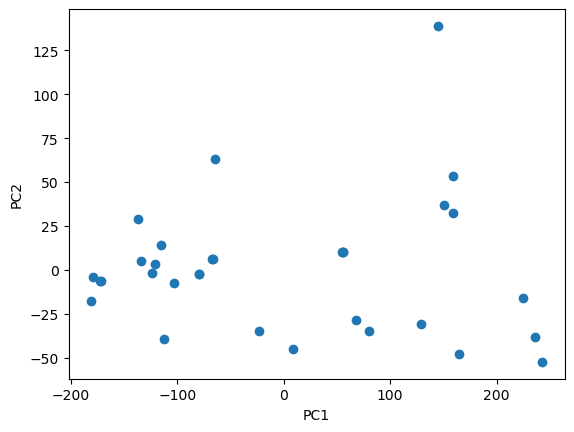

In [22]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(cars)
cars_pca = pca.transform(cars)
#plotting
ax = plt.gca()
ax.scatter(cars_pca[:,0], cars_pca[:,1])
t = ax.set_xlabel('PCA1')
t = ax.set_ylabel('PCA2')

3. Produce a scree plot and analyse how much variance is captured in the first 2 components.

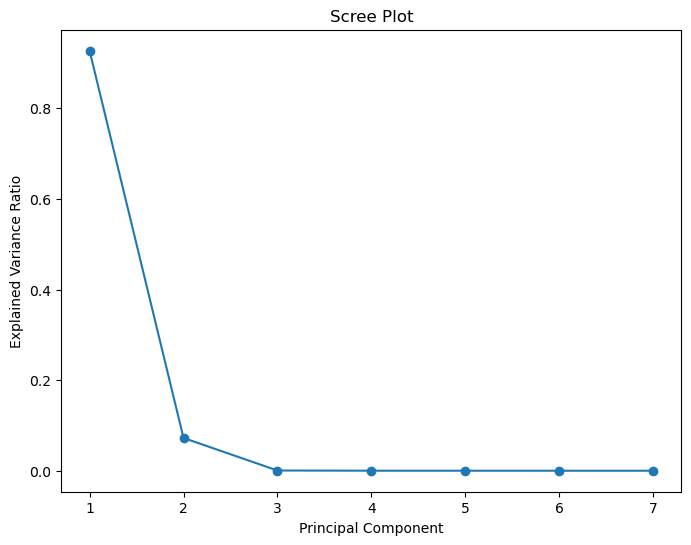

In [33]:
explained_variance = pca.explained_variance_ratio_
# Create a scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')

plt.show()

4. Plot the covariance matrix of the dataset. What stands out? 

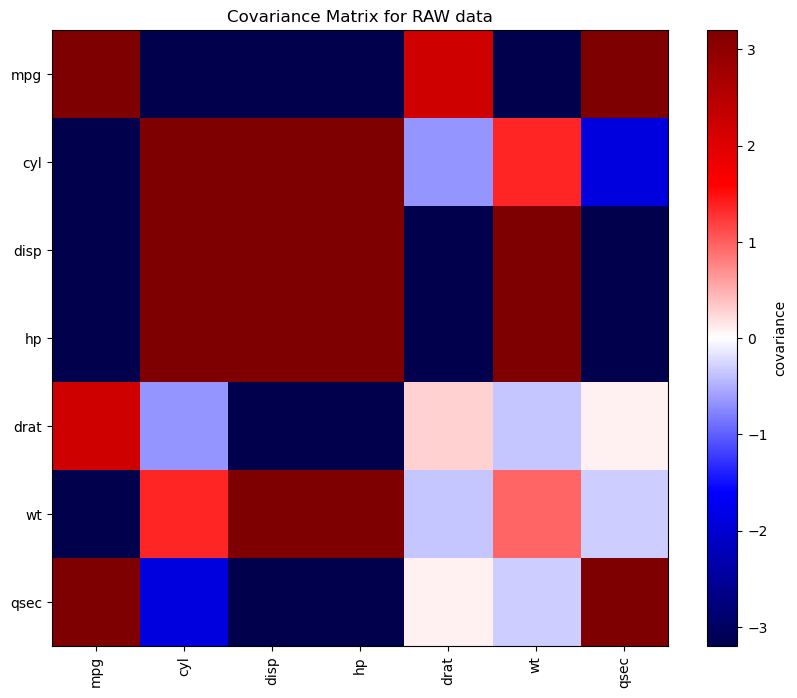

In [27]:
# Calculate the covariance matrix
covariance_matrix = cars.cov()

# Create a heatmap of the covariance matrix
plt.figure(figsize=(10, 8))
img = plt.imshow(covariance_matrix, cmap='seismic', vmin=-3.2, vmax=3.2)
plt.colorbar(img, label='covariance')
plt.title('Covariance Matrix for RAW data')
plt.xticks(range(len(cars.columns)), cars.columns, rotation=90)
plt.yticks(range(len(cars.columns)), cars.columns)
plt.show()

Positive Correlations: Bright regions in the heatmap indicate positive correlations between pairs of features. For example, you might observe positive correlations between 'mpg' and 'qsec,' 'disp' and 'hp,' etc.

Negative Correlations: Darkegions in the heatmap indicate negative correlations between pairs of features. You may notice negative correlations between 'mpg' and 'hp,' 'mpg' and 'wt,' etc.

High Variance Along the Diagonal: The diagonal of the covariance matrix represents the variances of individual features. The brighter the diagonal elements, the higher the variance of those features.

The covariance matrix heatmap helps you identify which features are correlated (positively or negatively) and which features have high variances. These insights can be valuable for feature selection, dimensionality reduction, and data analysis.

5. Look at the components of the dataset. Which features are highly represented in the first two components?

Task 5: Normalise and observe the effect (the variance bug)

 1. Normalise the data to zero mean and unit variance and repeat the steps above. 

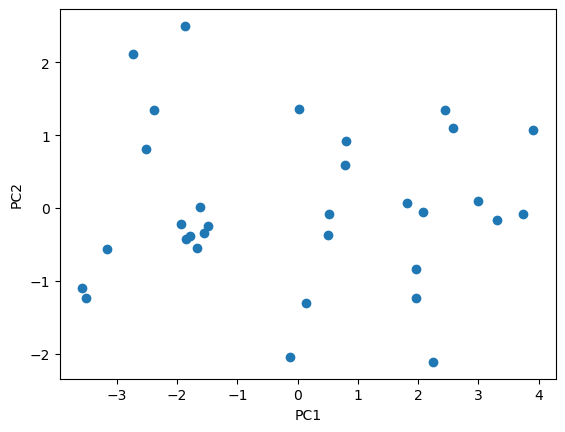

In [30]:
from sklearn import preprocessing as pp
ss = pp.StandardScaler()
ss.fit(cars)
pca_norm = PCA()
pca_norm.fit(ss.transform(cars)) # note the composition of the commands
cars_pca_norm = pca_norm.transform(ss.transform(cars))

#plotting
ax = plt.gca()
ax.scatter(iris_pca_norm[:,0], iris_pca_norm[:,1])
t = ax.set_xlabel('PC1')
t = ax.set_ylabel('PC2')

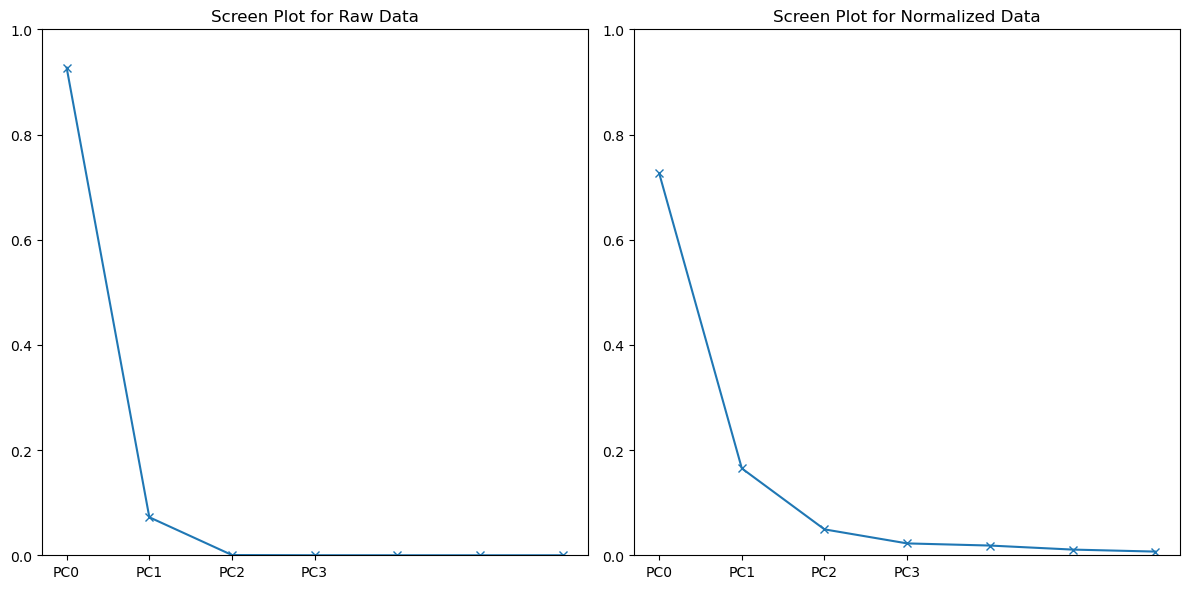

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].set_title('Screen Plot for Raw Data')
expl_var = pca.explained_variance_ratio_
axes[0].plot(expl_var, marker='x')
axes[0].set_ylim(0,1.)
axes[0].set_xticks([0,1,2,3])
axes[0].set_xticklabels(["PC{}".format(i) for i in range(4)])

#expl_var_norm = pca_norm.explained_variance_ratio_
axes[1].set_title('Screen Plot for Normalized Data')
expl_var_norm = pca_norm.explained_variance_ratio_
axes[1].plot(expl_var_norm, marker='x')
axes[1].set_ylim(0,1.)
axes[1].set_xticks([0,1,2,3])
axes[1].set_xticklabels(["PC{}".format(i) for i in range(4)])

plt.tight_layout()
plt.show()

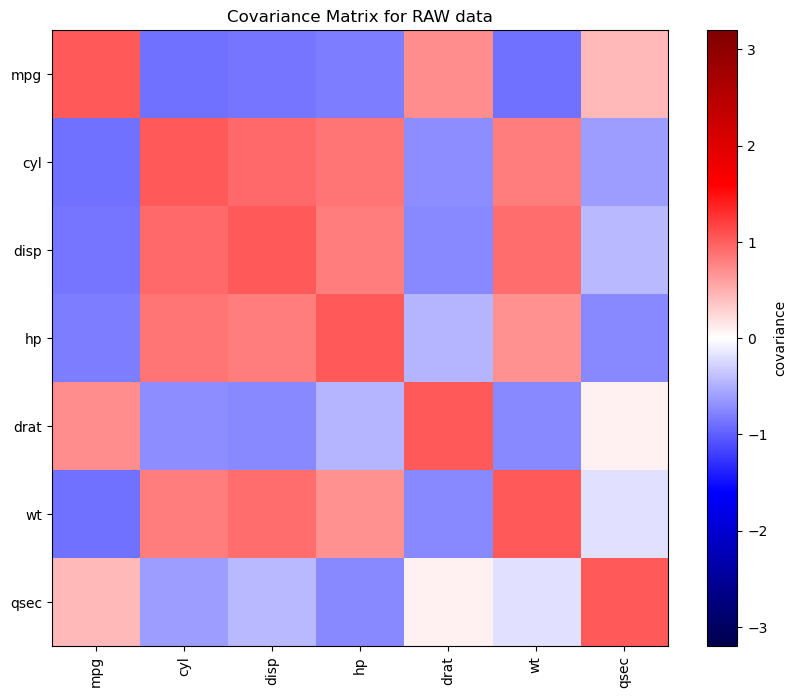

In [37]:
covmat_norm = pca_norm.get_covariance()
# Create a heatmap of the covariance matrix
plt.figure(figsize=(10, 8))
img = plt.imshow(covmat_norm, cmap='seismic', vmin=-3.2, vmax=3.2)
plt.colorbar(img, label='covariance')
plt.title('Covariance Matrix for RAW data')
plt.xticks(range(len(cars.columns)), cars.columns, rotation=90)
plt.yticks(range(len(cars.columns)), cars.columns)
plt.show()

# Coronavirus epidemic dynamics

Here's a task for advanced students. As you all are aware, last spring we saw the outbreak of Covid-19, aka coronavirus. Here, we're going to analyse a dataset from the beginning of the outbreak, when it was just about to spread around the world. 

### Task: Explore data on kaggle.com
1. Go to the website on the kaggle site: https://www.kaggle.com/sudalairajkumar/novel-corona-virus-2019-dataset 
2. Inspect the data on the website and the various ways the site lets you explore it. Registration on the website is not necessary.



## Working with the Coronavirus outbreak data
1. The coronavirus dataset is provided on canvas. Download and save it in the same folder as this notebook.
2. Unzip the data.
3. Verify that the folder in which this notebook resides should now contain a sub-folder named `novel-corona-virus-2019-dataset`

First we load the main dataset into a DataFrame:

In [ ]:
df = pd.read_csv('novel-corona-virus-2019-dataset/2019_nCoV_data.csv')
df

If this fails then please check again whether the dataset folder is unzipped and resides in the same folder as this notebook. Check that the filename in the command matches the filename of the data set on disk.

The `Sno` column contains the serial number and is identical with the aut-generated index column. let's set the Index to track the `Sno` column:

In [ ]:
df = df.set_index('Sno')
df 

Let's explore the data types.

### Task 6: 
Which features are numeric? Which are continuous? Which are categorical?

## Initial exploration
Let's plot the number of number of confirmed cases for the whole data set.

In [ ]:
df['Confirmed'].plot()

### Task 7

Is this the plot you expected? Why not? 

Solution: The above command naively plots the whole column, but ignores the structure of the data set, where each line applies to a different province/state, or even country.

We need to filter by country! Let's look only at the Hubei province, the root of the outbreak:

In [ ]:
df.loc[df['Province/State'] == 'Hubei']

That looks better! Let's plot those values:

In [ ]:
df.loc[df['Province/State'] == 'Hubei'].plot()

Note how the `.plot()` function of the `DataFrame` object already gives us a plot of all numerical features, complete with a legend!

The plot is still lackiong though; It needs for example:
* Dates on the x-axis
* proper labels on the y-axis

### Task 8 (advanced and optional)
* Read the documentation of the `DataFrame.plot` command to learn how to make it plot the date on the x-axis.
* use the `ax = gca()` method the get an axis object, and call the `set_ylabel()` method to set an appropriate y-label.

### Task 9 (advanced and optional)
* Plot the data for all of China.
* Aggregate the data for the rest of the world and plot it.

## That's it for today!
We have covered have learnt:
* Essential `pandas`; how to create, address and modify `pandas` `DataFrame`s.
* How to perform a data science campaign using PCA.
* Initial loading and ploting of time-series data.

Next week we'll continue our analysis of the coronavirus data, with a special focus on visualisation.